*© 2026 Zettnq · oi-volume-signal-research · MIT License*
### 02. Signal Generation & Clustering
Generation of long/short signals (exhaustion pattern), episode IDs and clustering analysis. Artifact: ..._signals.parquet. Figures: figures/data/.

In [1]:
from pathlib import Path

import oivdc_research  # installed via `pip install -e .`

# repo root: .../repo/src/oivdcr_research/__init__.py -> parents[2] = repo
PROJECT_ROOT = Path(oivdc_research.__file__).resolve().parents[2]

import numpy as np
import pandas as pd

from oivdc_research.config import get_config

# Reproducibility parameters — edit here.
ASSET = "btcusdt"
TIMEFRAME = "1h"

CONFIG = get_config(
    project_root=PROJECT_ROOT,
    raw_csv_path=PROJECT_ROOT / "data" / "raw" / f"{ASSET}_{TIMEFRAME}.csv",
    timeframe=TIMEFRAME,
    asset=ASSET,
)

In [2]:
from oivdc_research.data import load_validated_data
from oivdc_research.signals import add_signal_columns, summarize_signal_counts, save_signals
from oivdc_research.clustering import add_episode_ids, analyze_signal_runs, get_clustering_summary

df = load_validated_data(CONFIG)
df = add_signal_columns(df, CONFIG)
df = add_episode_ids(df)

print(summarize_signal_counts(df))

  signal_type  count        pct
0        long   8263  18.567705
1       short   8410  18.898027
2        none  27829  62.534268


In [3]:
long_runs = analyze_signal_runs(df, "long_signal")
short_runs = analyze_signal_runs(df, "short_signal")
clustering = get_clustering_summary(long_runs, short_runs)
print(clustering)

   signal_type  run_length  num_episodes  total_signals_in_episodes  \
0         long           1          5293                       5293   
1         long           2          1037                       2074   
2         long           3           211                        633   
3         long           4            55                        220   
4         long           5             5                         25   
5         long           6             3                         18   
6        short           1          5607                       5607   
7        short           2          1039                       2078   
8        short           3           178                        534   
9        short           4            39                        156   
10       short           5             7                         35   

    pct_of_signals  
0        64.056638  
1        25.099843  
2         7.660656  
3         2.662471  
4         0.302554  
5         0.217839  


Clustering (~35% of signals in episodes of length ≥ 2) compromises the independence of events → we therefore use episode-based aggregation (04).

Saved: reports/figures/data/signal_counts_over_time.png


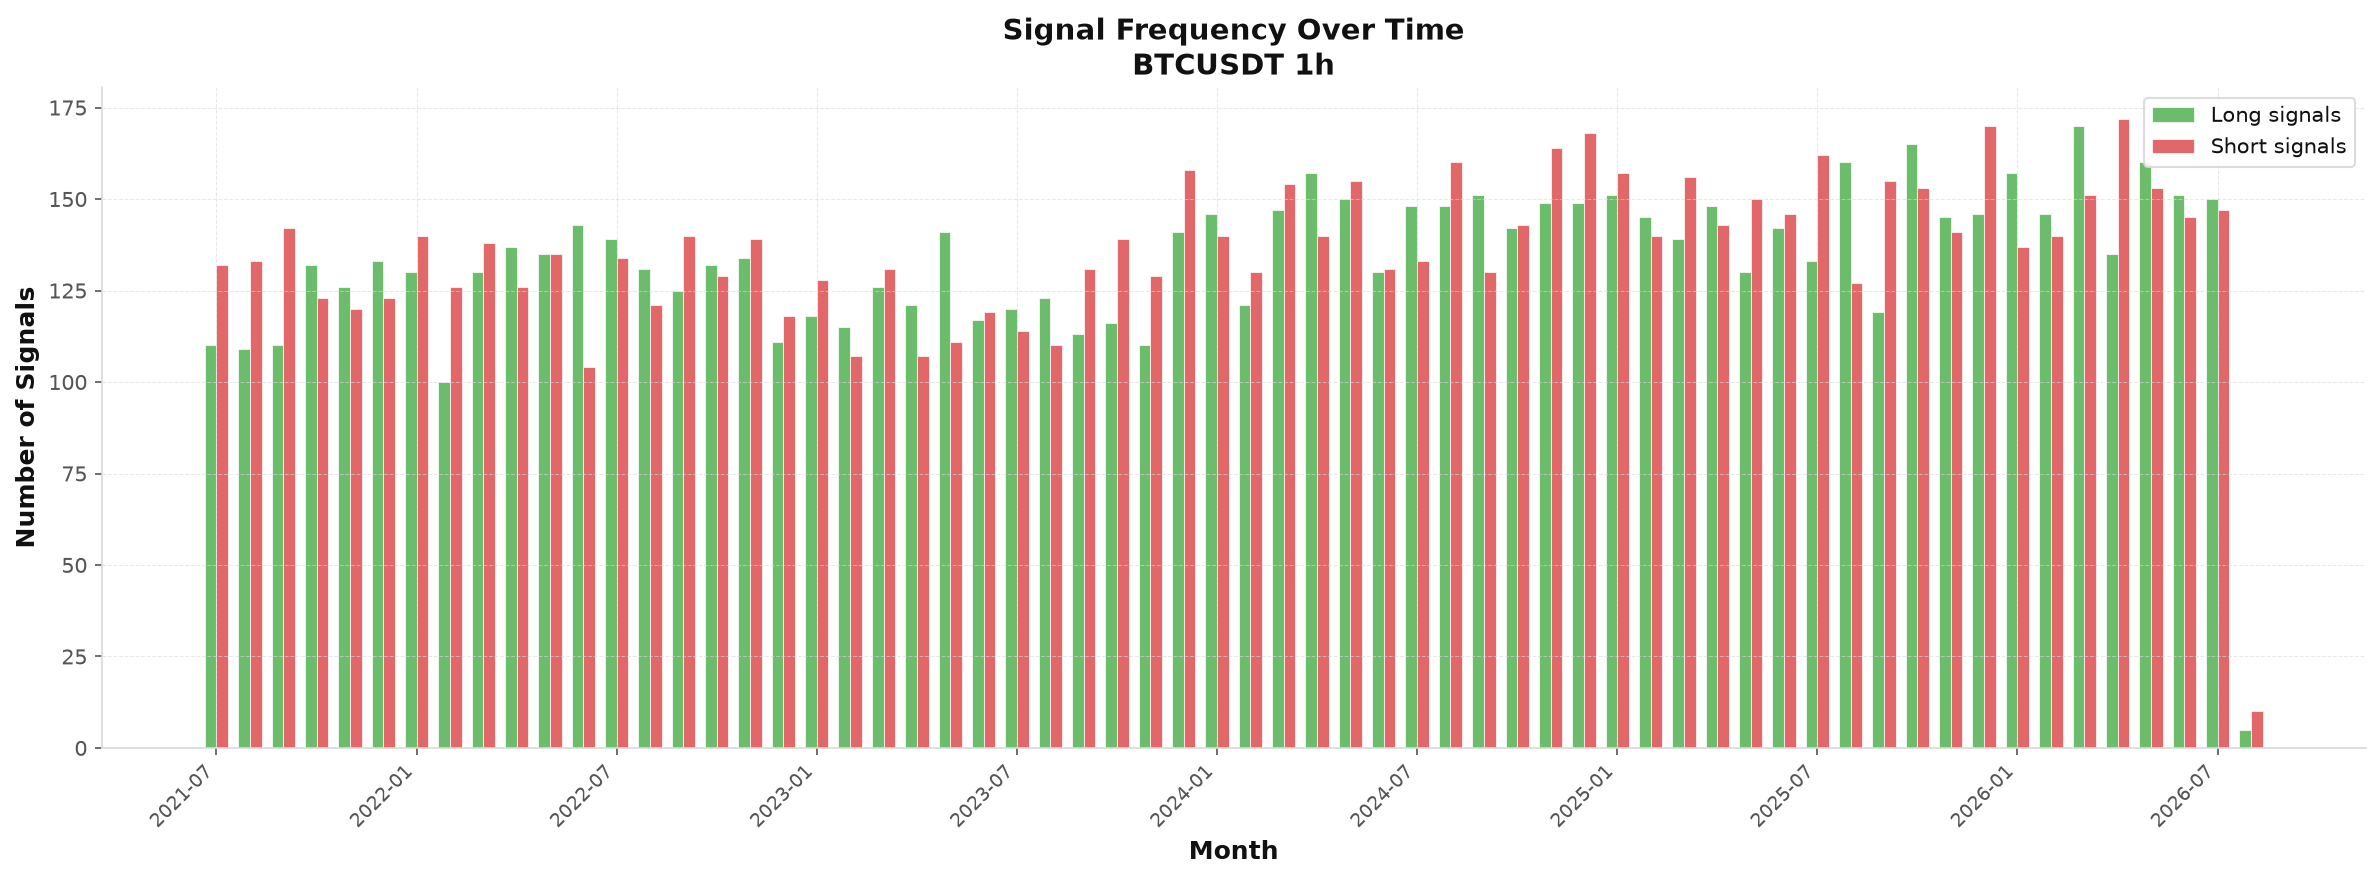

Saved: reports/figures/data/clustering_distribution.png


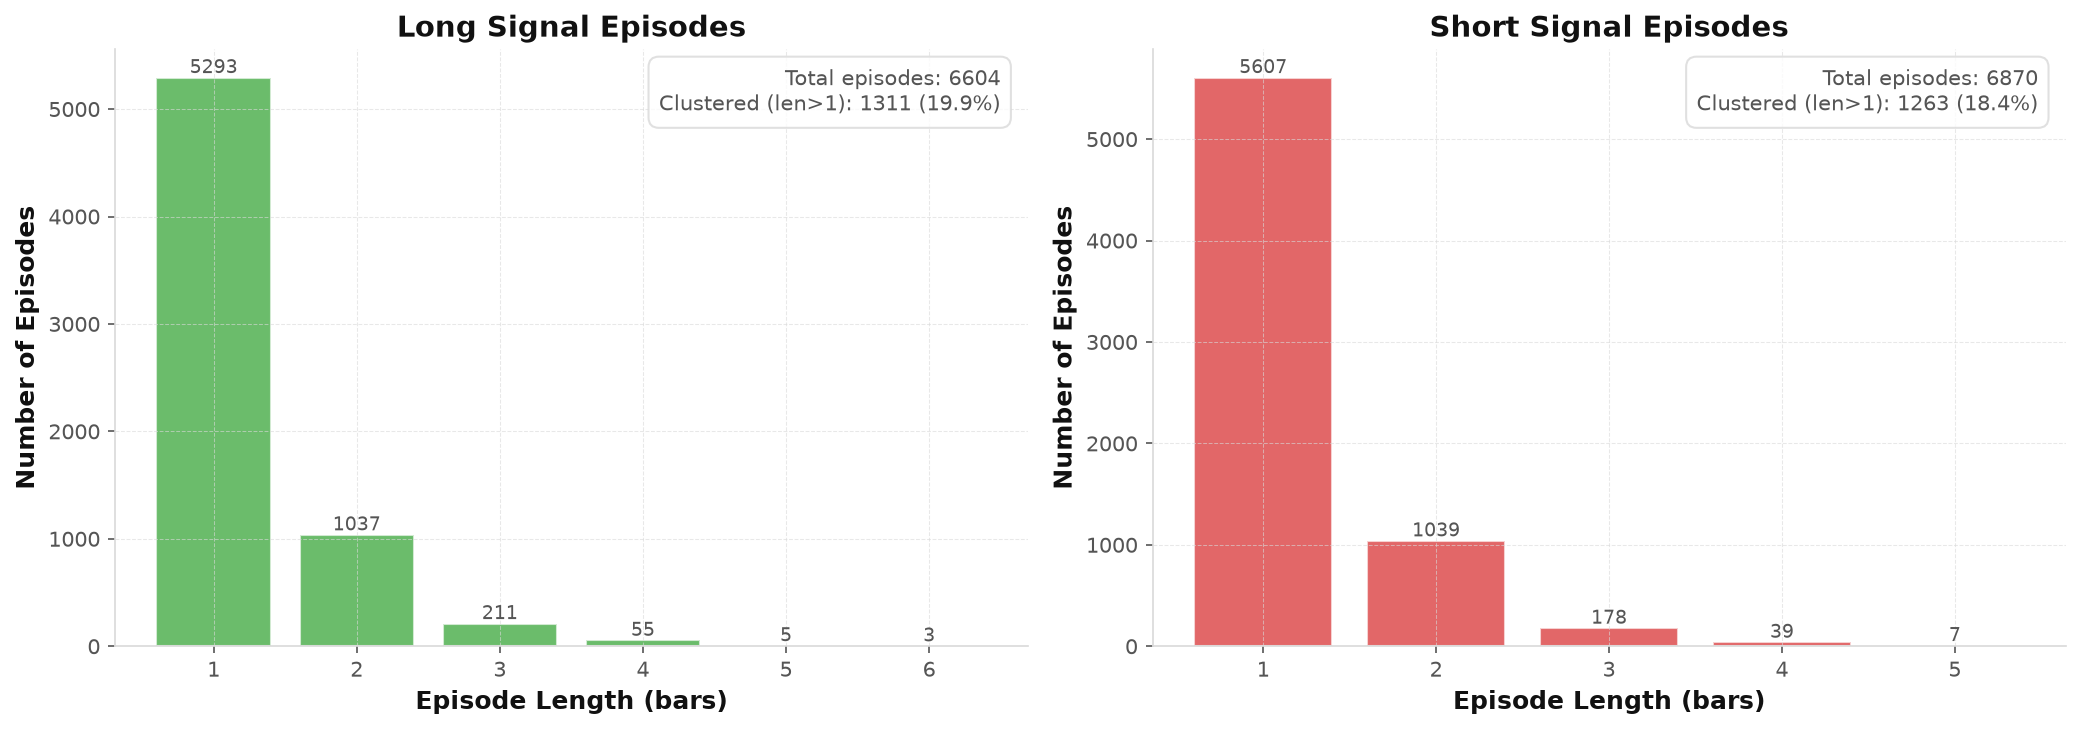

In [4]:
save_signals(df, CONFIG)

from oivdc_research.plotting import plot_signal_counts_over_time, plot_clustering_distribution

fig_dir = CONFIG.figures_dir_for("data")
plot_signal_counts_over_time(df, CONFIG, fig_dir / "signal_counts_over_time.png")
plot_clustering_distribution(long_runs, short_runs,
                             fig_dir / "clustering_distribution.png",
                             theme=CONFIG.plot_theme)